# 02. Event Funnel Analysis

이 노트북은 `01_raw_data_audit.ipynb`에서 생성한 `data/processed/events_clean.csv` 또는 `events_clean.parquet`을 기반으로 이커머스 행동 퍼널을 분석한다.

핵심 질문은 다음과 같다.

- 사용자는 `view → addtocart → transaction` 단계에서 어디서 가장 많이 이탈하는가?
- 이벤트 수 기준과 사용자 수 기준의 퍼널은 어떻게 다른가?
- 일자별/월별 전환율은 어떤 흐름을 보이는가?
- 재방문 사용자와 단일 방문 사용자의 행동 차이가 있는가?
- A/B Test 설계 시 어떤 전환 지표를 baseline metric으로 삼는 것이 적절한가?

In [1]:
# ============================================================
# 0. Library Setting
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 2.2.3
numpy: 2.1.3


In [2]:
# ============================================================
# 1. Project Path Setting
# ============================================================

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
CHART_DIR = OUTPUT_DIR / "charts"
TABLE_DIR = OUTPUT_DIR / "tables"

for path in [PROCESSED_DIR, OUTPUT_DIR, CHART_DIR, TABLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

EVENTS_PARQUET_PATH = PROCESSED_DIR / "events_clean.parquet"
EVENTS_CSV_PATH = PROCESSED_DIR / "events_clean.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("EVENTS_PARQUET_PATH exists:", EVENTS_PARQUET_PATH.exists())
print("EVENTS_CSV_PATH exists:", EVENTS_CSV_PATH.exists())

PROJECT_ROOT: c:\Users\USER\Desktop\ecommerce_ab_test_project
EVENTS_PARQUET_PATH exists: False
EVENTS_CSV_PATH exists: True


In [3]:
# ============================================================
# 2. Utility Functions
# ============================================================

def save_table(df: pd.DataFrame, filename: str, index: bool = False) -> Path:
    save_path = TABLE_DIR / filename
    df.to_csv(save_path, index=index, encoding="utf-8-sig")
    print(f"saved: {save_path}")
    return save_path


def save_chart(filename: str) -> Path:
    save_path = CHART_DIR / filename
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"saved: {save_path}")
    return save_path


def add_bar_labels(ax, values, fmt="{:,.0f}"):
    for i, v in enumerate(values):
        ax.text(i, v, fmt.format(v), ha="center", va="bottom", fontsize=10)

In [4]:
# ============================================================
# 3. Load Processed Event Data
# ============================================================

if EVENTS_PARQUET_PATH.exists():
    events = pd.read_parquet(EVENTS_PARQUET_PATH)
elif EVENTS_CSV_PATH.exists():
    events = pd.read_csv(EVENTS_CSV_PATH)
else:
    raise FileNotFoundError(
        "events_clean.parquet 또는 events_clean.csv가 data/processed/에 없습니다. "
        "먼저 01_raw_data_audit.ipynb를 실행해 주세요."
    )

print("events shape:", events.shape)
display(events.head())
display(events.dtypes)

events shape: (2756101, 8)


,timestamp,visitorid,event,itemid,transactionid,event_time,event_date,event_month
0,1433221332117,257597,view,355908,NaN,2015-06-02 05:02:12.117,2015-06-02,2015-06
1,1433224214164,992329,view,248676,NaN,2015-06-02 05:50:14.164,2015-06-02,2015-06
2,1433221999827,111016,view,318965,NaN,2015-06-02 05:13:19.827,2015-06-02,2015-06
3,1433221955914,483717,view,253185,NaN,2015-06-02 05:12:35.914,2015-06-02,2015-06
4,1433221337106,951259,view,367447,NaN,2015-06-02 05:02:17.106,2015-06-02,2015-06


timestamp          int64
visitorid          int64
event             object
itemid             int64
transactionid    float64
event_time        object
event_date        object
event_month       object
dtype: object

In [5]:
# ============================================================
# 4. Datetime and Type Validation
# ============================================================

if "event_time" not in events.columns:
    if "timestamp" not in events.columns:
        raise ValueError("timestamp 또는 event_time 컬럼이 필요합니다.")
    events["event_time"] = pd.to_datetime(events["timestamp"], unit="ms")
else:
    events["event_time"] = pd.to_datetime(events["event_time"])

if "event_date" not in events.columns:
    events["event_date"] = events["event_time"].dt.date
else:
    events["event_date"] = pd.to_datetime(events["event_date"]).dt.date

if "event_month" not in events.columns:
    events["event_month"] = events["event_time"].dt.to_period("M").astype(str)

events["event"] = events["event"].astype("category")

print("event period:", events["event_time"].min(), "~", events["event_time"].max())
print("unique visitors:", f"{events['visitorid'].nunique():,}")
print("unique items:", f"{events['itemid'].nunique():,}")
display(events.head())

event period: 2015-05-03 03:00:04.384000 ~ 2015-09-18 02:59:47.788000
unique visitors: 1,407,580
unique items: 235,061


,timestamp,visitorid,event,itemid,transactionid,event_time,event_date,event_month
0,1433221332117,257597,view,355908,NaN,2015-06-02 05:02:12.117,2015-06-02,2015-06
1,1433224214164,992329,view,248676,NaN,2015-06-02 05:50:14.164,2015-06-02,2015-06
2,1433221999827,111016,view,318965,NaN,2015-06-02 05:13:19.827,2015-06-02,2015-06
3,1433221955914,483717,view,253185,NaN,2015-06-02 05:12:35.914,2015-06-02,2015-06
4,1433221337106,951259,view,367447,NaN,2015-06-02 05:02:17.106,2015-06-02,2015-06


## 1. Event Count Funnel

이벤트 수 기준 퍼널은 전체 플랫폼에서 각 행동이 몇 번 발생했는지를 보여준다. 동일 사용자가 여러 번 조회하거나 장바구니에 담을 수 있으므로, 이후 사용자 기준 퍼널과 함께 해석해야 한다.

In [6]:
# ============================================================
# 5. Event Count Funnel
# ============================================================

event_order = ["view", "addtocart", "transaction"]

event_count_funnel = (
    events["event"]
    .value_counts()
    .reindex(event_order)
    .fillna(0)
    .astype(int)
    .rename_axis("event")
    .reset_index(name="event_count")
)

event_count_funnel["event_share"] = event_count_funnel["event_count"] / event_count_funnel["event_count"].sum()
event_count_funnel["event_share_pct"] = event_count_funnel["event_share"] * 100

display(event_count_funnel)
save_table(event_count_funnel, "02_event_count_funnel.csv")

,event,event_count,event_share,event_share_pct
0,view,2664312,0.9667,96.6696
1,addtocart,69332,0.0252,2.5156
2,transaction,22457,0.0081,0.8148


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\02_event_count_funnel.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/02_event_count_funnel.csv')

saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\charts\02_event_count_funnel.png


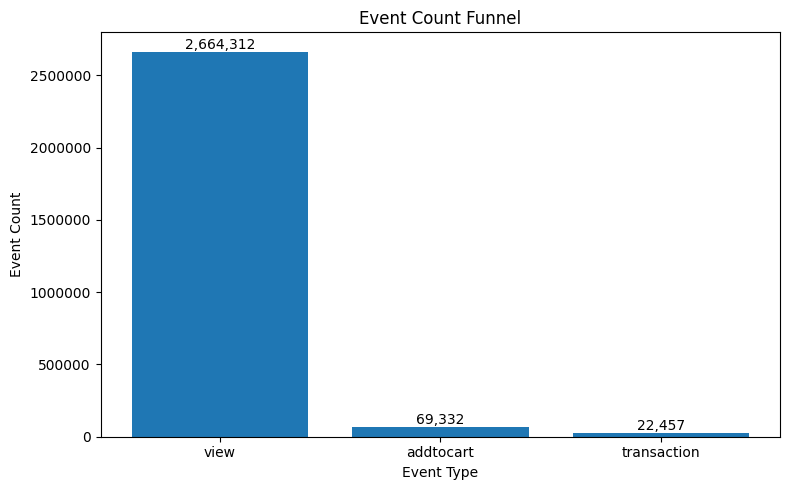

In [7]:
# ============================================================
# 6. Event Count Funnel Chart
# ============================================================

plt.figure(figsize=(8, 5))
ax = plt.gca()
ax.bar(event_count_funnel["event"], event_count_funnel["event_count"])
ax.set_title("Event Count Funnel")
ax.set_xlabel("Event Type")
ax.set_ylabel("Event Count")
ax.ticklabel_format(style="plain", axis="y")
add_bar_labels(ax, event_count_funnel["event_count"].tolist())
plt.tight_layout()
save_chart("02_event_count_funnel.png")
plt.show()

## 2. User-Level Funnel

사용자 기준 퍼널은 각 단계에 도달한 고유 사용자 수를 계산한다. 이 프로젝트의 핵심 baseline은 이벤트 수보다 사용자 기준 전환율이다. A/B Test에서는 일반적으로 사용자 단위 randomization과 conversion 여부를 비교하기 때문이다.

In [8]:
# ============================================================
# 7. User-Level Funnel
# ============================================================

visitor_sets = {
    "view": set(events.loc[events["event"] == "view", "visitorid"].unique()),
    "addtocart": set(events.loc[events["event"] == "addtocart", "visitorid"].unique()),
    "transaction": set(events.loc[events["event"] == "transaction", "visitorid"].unique()),
}

n_view = len(visitor_sets["view"])
n_cart = len(visitor_sets["addtocart"])
n_purchase = len(visitor_sets["transaction"])

view_to_cart = n_cart / n_view if n_view else np.nan
cart_to_purchase = n_purchase / n_cart if n_cart else np.nan
view_to_purchase = n_purchase / n_view if n_view else np.nan

user_funnel = pd.DataFrame({
    "stage": ["View", "Add to Cart", "Purchase"],
    "event": event_order,
    "unique_visitors": [n_view, n_cart, n_purchase],
})

user_funnel["stage_share_of_view_users"] = user_funnel["unique_visitors"] / n_view
user_funnel["dropoff_from_previous"] = user_funnel["unique_visitors"].shift(1) - user_funnel["unique_visitors"]
user_funnel["dropoff_rate_from_previous"] = user_funnel["dropoff_from_previous"] / user_funnel["unique_visitors"].shift(1)

display(user_funnel)
save_table(user_funnel, "02_user_level_funnel.csv")

,stage,event,unique_visitors,stage_share_of_view_users,dropoff_from_previous,dropoff_rate_from_previous
0,View,view,1404179,1.0000,NaN,NaN
1,Add to Cart,addtocart,37722,0.0269,"1,366,457.0000",0.9731
2,Purchase,transaction,11719,0.0083,"26,003.0000",0.6893


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\02_user_level_funnel.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/02_user_level_funnel.csv')

In [9]:
# ============================================================
# 8. User-Level Conversion Summary
# ============================================================

conversion_summary = pd.DataFrame({
    "conversion_step": ["View → Add to Cart", "Add to Cart → Purchase", "View → Purchase"],
    "numerator": [n_cart, n_purchase, n_purchase],
    "denominator": [n_view, n_cart, n_view],
})
conversion_summary["conversion_rate"] = conversion_summary["numerator"] / conversion_summary["denominator"]
conversion_summary["conversion_rate_pct"] = conversion_summary["conversion_rate"] * 100

display(conversion_summary)
save_table(conversion_summary, "02_user_level_conversion_summary.csv")

,conversion_step,numerator,denominator,conversion_rate,conversion_rate_pct
0,View → Add to Cart,37722,1404179,0.0269,2.6864
1,Add to Cart → Purchase,11719,37722,0.3107,31.0668
2,View → Purchase,11719,1404179,0.0083,0.8346


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\02_user_level_conversion_summary.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/02_user_level_conversion_summary.csv')

saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\charts\02_user_level_funnel.png


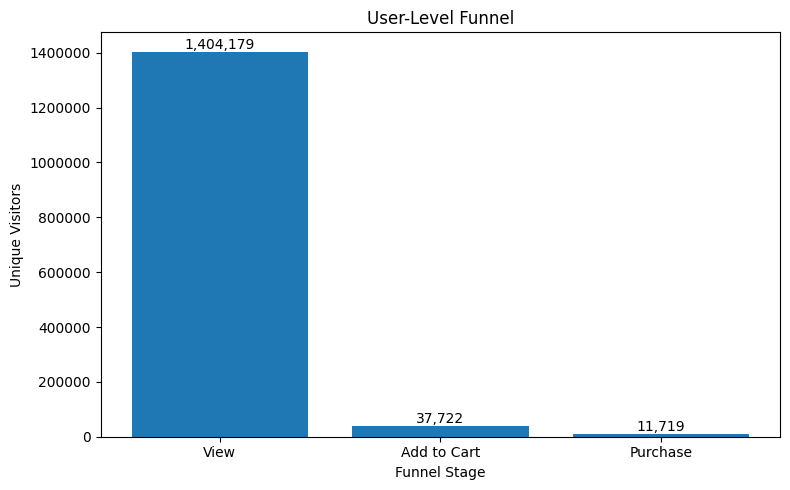

In [10]:
# ============================================================
# 9. User-Level Funnel Chart
# ============================================================

plt.figure(figsize=(8, 5))
ax = plt.gca()
ax.bar(user_funnel["stage"], user_funnel["unique_visitors"])
ax.set_title("User-Level Funnel")
ax.set_xlabel("Funnel Stage")
ax.set_ylabel("Unique Visitors")
ax.ticklabel_format(style="plain", axis="y")
add_bar_labels(ax, user_funnel["unique_visitors"].tolist())
plt.tight_layout()
save_chart("02_user_level_funnel.png")
plt.show()

saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\charts\02_user_level_conversion_rates.png


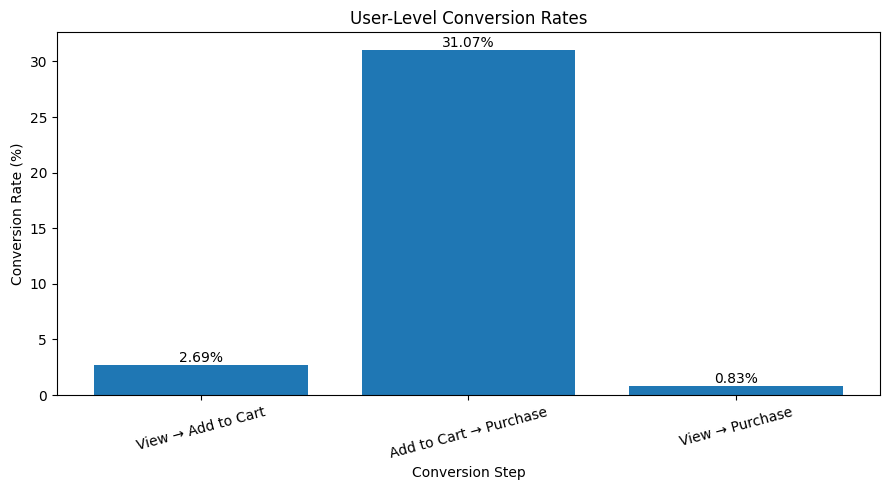

In [11]:
# ============================================================
# 10. User-Level Conversion Rate Chart
# ============================================================

plt.figure(figsize=(9, 5))
ax = plt.gca()
ax.bar(conversion_summary["conversion_step"], conversion_summary["conversion_rate_pct"])
ax.set_title("User-Level Conversion Rates")
ax.set_xlabel("Conversion Step")
ax.set_ylabel("Conversion Rate (%)")
for i, v in enumerate(conversion_summary["conversion_rate_pct"]):
    ax.text(i, v, f"{v:.2f}%", ha="center", va="bottom", fontsize=10)
plt.xticks(rotation=15)
plt.tight_layout()
save_chart("02_user_level_conversion_rates.png")
plt.show()

## 3. User Behavior Aggregation

사용자 단위로 조회 수, 장바구니 수, 구매 수를 집계한다. 이 결과는 이후 사용자 세그먼트 분석과 A/B Test 대상 정의에 활용할 수 있다.

In [12]:
# ============================================================
# 11. User-Level Behavior Table
# ============================================================

user_event_counts = (
    events
    .pivot_table(index="visitorid", columns="event", values="itemid", aggfunc="count", fill_value=0, observed=False)
    .reset_index()
)

for col in event_order:
    if col not in user_event_counts.columns:
        user_event_counts[col] = 0

user_event_counts = user_event_counts[["visitorid"] + event_order]
user_event_counts = user_event_counts.rename(columns={
    "view": "view_count",
    "addtocart": "cart_count",
    "transaction": "purchase_count",
})

user_event_counts["has_view"] = user_event_counts["view_count"] > 0
user_event_counts["has_cart"] = user_event_counts["cart_count"] > 0
user_event_counts["has_purchase"] = user_event_counts["purchase_count"] > 0

user_event_counts["cart_per_view"] = np.where(
    user_event_counts["view_count"] > 0,
    user_event_counts["cart_count"] / user_event_counts["view_count"],
    np.nan,
)
user_event_counts["purchase_per_view"] = np.where(
    user_event_counts["view_count"] > 0,
    user_event_counts["purchase_count"] / user_event_counts["view_count"],
    np.nan,
)

print("user_event_counts shape:", user_event_counts.shape)
display(user_event_counts.head())
save_table(user_event_counts, "02_user_event_counts.csv")

user_event_counts shape: (1407580, 9)


event,visitorid,view_count,cart_count,purchase_count,has_view,has_cart,has_purchase,cart_per_view,purchase_per_view
0,0,3,0,0,True,False,False,0.0000,0.0000
1,1,1,0,0,True,False,False,0.0000,0.0000
2,2,8,0,0,True,False,False,0.0000,0.0000
3,3,1,0,0,True,False,False,0.0000,0.0000
4,4,1,0,0,True,False,False,0.0000,0.0000


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\02_user_event_counts.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/02_user_event_counts.csv')

In [13]:
# ============================================================
# 12. User Behavior Distribution Summary
# ============================================================

user_behavior_summary = (
    user_event_counts[["view_count", "cart_count", "purchase_count", "cart_per_view", "purchase_per_view"]]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    .T
    .reset_index()
    .rename(columns={"index": "metric"})
)

display(user_behavior_summary)
save_table(user_behavior_summary, "02_user_behavior_distribution_summary.csv")

,event,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
0,view_count,"1,407,580.0000",1.8928,10.9937,0.0000,1.0000,1.0000,2.0000,3.0000,5.0000,12.0000,"6,479.0000"
1,cart_count,"1,407,580.0000",0.0493,1.1651,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,719.0000
2,purchase_count,"1,407,580.0000",0.0160,0.8261,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,559.0000
3,cart_per_view,"1,404,179.0000",0.0136,0.1296,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,31.0000
4,purchase_per_view,"1,404,179.0000",0.0035,0.0529,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,6.0000


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\02_user_behavior_distribution_summary.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/02_user_behavior_distribution_summary.csv')

In [14]:
# ============================================================
# 13. Repeat Visitor Segmentation
# ============================================================

user_event_counts["visitor_segment"] = np.where(
    user_event_counts["view_count"] >= 2,
    "repeat_viewer",
    "single_viewer",
)

segment_summary = (
    user_event_counts
    .groupby("visitor_segment", as_index=False)
    .agg(
        users=("visitorid", "nunique"),
        avg_view_count=("view_count", "mean"),
        avg_cart_count=("cart_count", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        cart_users=("has_cart", "sum"),
        purchase_users=("has_purchase", "sum"),
    )
)
segment_summary["cart_conversion_rate"] = segment_summary["cart_users"] / segment_summary["users"]
segment_summary["purchase_conversion_rate"] = segment_summary["purchase_users"] / segment_summary["users"]

display(segment_summary)
save_table(segment_summary, "02_repeat_visitor_segment_summary.csv")

,visitor_segment,users,avg_view_count,avg_cart_count,avg_purchase_count,cart_users,purchase_users,cart_conversion_rate,purchase_conversion_rate
0,repeat_viewer,396449,4.1786,0.1391,0.0495,25940,9111,0.0654,0.0230
1,single_viewer,1011131,0.9966,0.0140,0.0028,11782,2608,0.0117,0.0026


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\02_repeat_visitor_segment_summary.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/02_repeat_visitor_segment_summary.csv')

## 4. Daily Funnel Trend

일자별로 view, addtocart, transaction 사용자 수와 전환율을 계산한다. 일자별 conversion은 전체 기간 기준 사용자 전환율과 다르므로, 시간 흐름을 보는 보조 지표로 사용한다.

In [15]:
# ============================================================
# 14. Daily Funnel Trend
# ============================================================

daily_event_users = (
    events
    .groupby(["event_date", "event"], observed=False)["visitorid"]
    .nunique()
    .reset_index(name="unique_visitors")
)

daily_funnel = daily_event_users.pivot(index="event_date", columns="event", values="unique_visitors").fillna(0).reset_index()
for col in event_order:
    if col not in daily_funnel.columns:
        daily_funnel[col] = 0

daily_funnel = daily_funnel[["event_date"] + event_order].rename(columns={
    "view": "view_users",
    "addtocart": "cart_users",
    "transaction": "purchase_users",
})

daily_funnel["view_to_cart_rate"] = np.where(daily_funnel["view_users"] > 0, daily_funnel["cart_users"] / daily_funnel["view_users"], np.nan)
daily_funnel["cart_to_purchase_rate"] = np.where(daily_funnel["cart_users"] > 0, daily_funnel["purchase_users"] / daily_funnel["cart_users"], np.nan)
daily_funnel["view_to_purchase_rate"] = np.where(daily_funnel["view_users"] > 0, daily_funnel["purchase_users"] / daily_funnel["view_users"], np.nan)

display(daily_funnel.head())
display(daily_funnel.tail())
save_table(daily_funnel, "02_daily_funnel_trend.csv")

event,event_date,view_users,cart_users,purchase_users,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
0,2015-05-03,7845,209,52,0.0266,0.2488,0.0066
1,2015-05-04,10995,304,101,0.0276,0.3322,0.0092
2,2015-05-05,13048,377,155,0.0289,0.4111,0.0119
3,2015-05-06,13659,388,151,0.0284,0.3892,0.0111
4,2015-05-07,13050,339,115,0.0260,0.3392,0.0088


event,event_date,view_users,cart_users,purchase_users,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
134,2015-09-14,13346,308,94,0.0231,0.3052,0.0070
135,2015-09-15,12647,302,89,0.0239,0.2947,0.0070
136,2015-09-16,6786,194,70,0.0286,0.3608,0.0103
137,2015-09-17,6231,154,32,0.0247,0.2078,0.0051
138,2015-09-18,1012,24,8,0.0237,0.3333,0.0079


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\02_daily_funnel_trend.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/02_daily_funnel_trend.csv')

saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\charts\02_daily_funnel_users.png


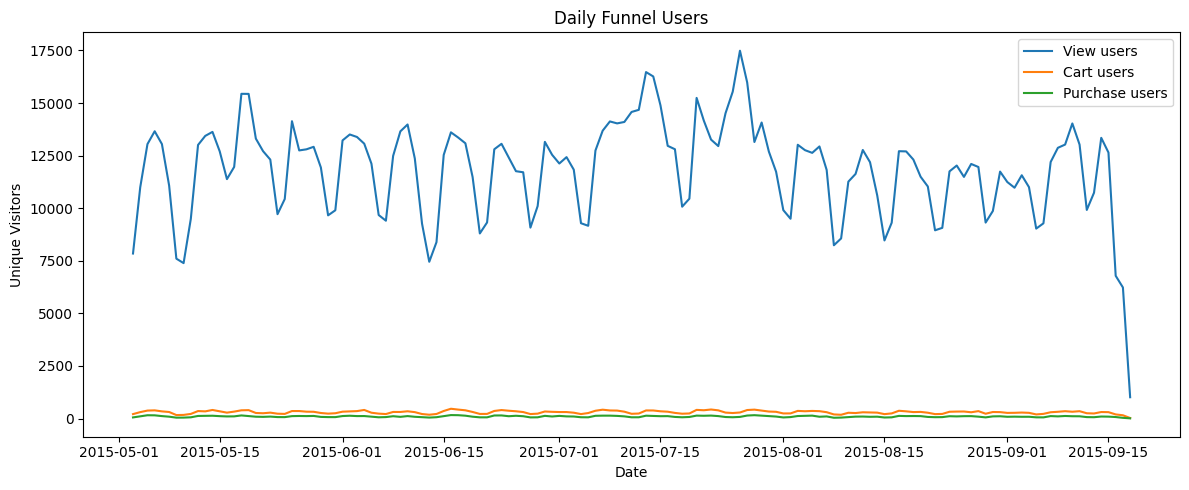

In [16]:
# ============================================================
# 15. Daily User Trend Chart
# ============================================================

plot_df = daily_funnel.copy()
plot_df["event_date"] = pd.to_datetime(plot_df["event_date"])

plt.figure(figsize=(12, 5))
plt.plot(plot_df["event_date"], plot_df["view_users"], label="View users")
plt.plot(plot_df["event_date"], plot_df["cart_users"], label="Cart users")
plt.plot(plot_df["event_date"], plot_df["purchase_users"], label="Purchase users")
plt.title("Daily Funnel Users")
plt.xlabel("Date")
plt.ylabel("Unique Visitors")
plt.legend()
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
save_chart("02_daily_funnel_users.png")
plt.show()

saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\charts\02_daily_conversion_rate_trend.png


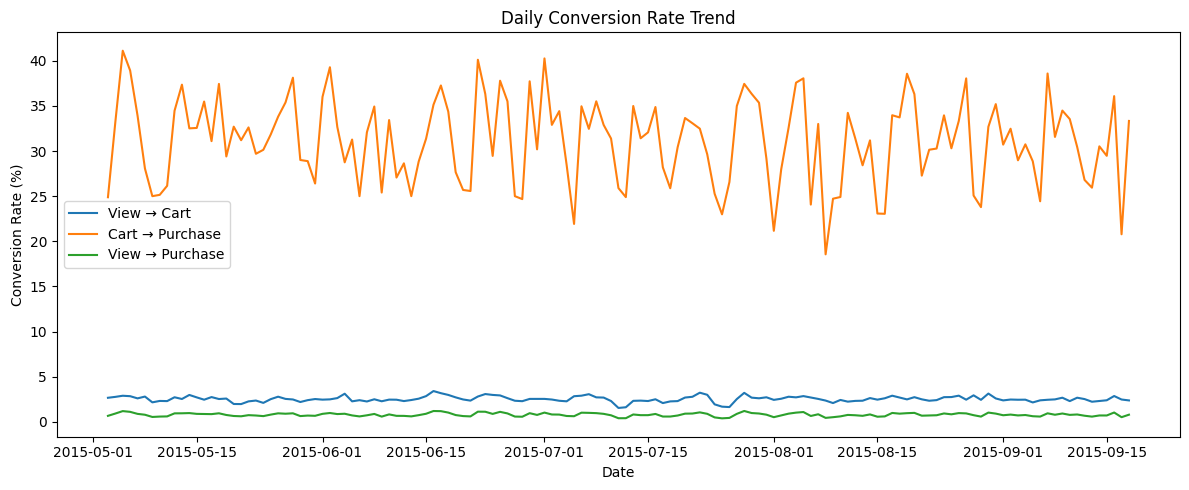

In [17]:
# ============================================================
# 16. Daily Conversion Trend Chart
# ============================================================

plt.figure(figsize=(12, 5))
plt.plot(plot_df["event_date"], plot_df["view_to_cart_rate"] * 100, label="View → Cart")
plt.plot(plot_df["event_date"], plot_df["cart_to_purchase_rate"] * 100, label="Cart → Purchase")
plt.plot(plot_df["event_date"], plot_df["view_to_purchase_rate"] * 100, label="View → Purchase")
plt.title("Daily Conversion Rate Trend")
plt.xlabel("Date")
plt.ylabel("Conversion Rate (%)")
plt.legend()
plt.tight_layout()
save_chart("02_daily_conversion_rate_trend.png")
plt.show()

## 5. Monthly Funnel Trend

월별 지표는 일별 지표보다 변동성이 작아 전체 추세를 해석하기 좋다.

In [18]:
# ============================================================
# 17. Monthly Funnel Trend
# ============================================================

monthly_event_users = (
    events
    .groupby(["event_month", "event"], observed=False)["visitorid"]
    .nunique()
    .reset_index(name="unique_visitors")
)

monthly_funnel = monthly_event_users.pivot(index="event_month", columns="event", values="unique_visitors").fillna(0).reset_index()
for col in event_order:
    if col not in monthly_funnel.columns:
        monthly_funnel[col] = 0

monthly_funnel = monthly_funnel[["event_month"] + event_order].rename(columns={
    "view": "view_users",
    "addtocart": "cart_users",
    "transaction": "purchase_users",
})

monthly_funnel["view_to_cart_rate"] = np.where(monthly_funnel["view_users"] > 0, monthly_funnel["cart_users"] / monthly_funnel["view_users"], np.nan)
monthly_funnel["cart_to_purchase_rate"] = np.where(monthly_funnel["cart_users"] > 0, monthly_funnel["purchase_users"] / monthly_funnel["cart_users"], np.nan)
monthly_funnel["view_to_purchase_rate"] = np.where(monthly_funnel["view_users"] > 0, monthly_funnel["purchase_users"] / monthly_funnel["view_users"], np.nan)

display(monthly_funnel)
save_table(monthly_funnel, "02_monthly_funnel_trend.csv")

event,event_month,view_users,cart_users,purchase_users,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
0,2015-05,306915,7949,2546,0.0259,0.3203,0.0083
1,2015-06,313218,8595,2728,0.0274,0.3174,0.0087
2,2015-07,376336,9434,2971,0.0251,0.3149,0.0079
3,2015-08,310203,8315,2498,0.0268,0.3004,0.0081
4,2015-09,173169,4331,1290,0.0250,0.2979,0.0074


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\02_monthly_funnel_trend.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/02_monthly_funnel_trend.csv')

saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\charts\02_monthly_conversion_rate_trend.png


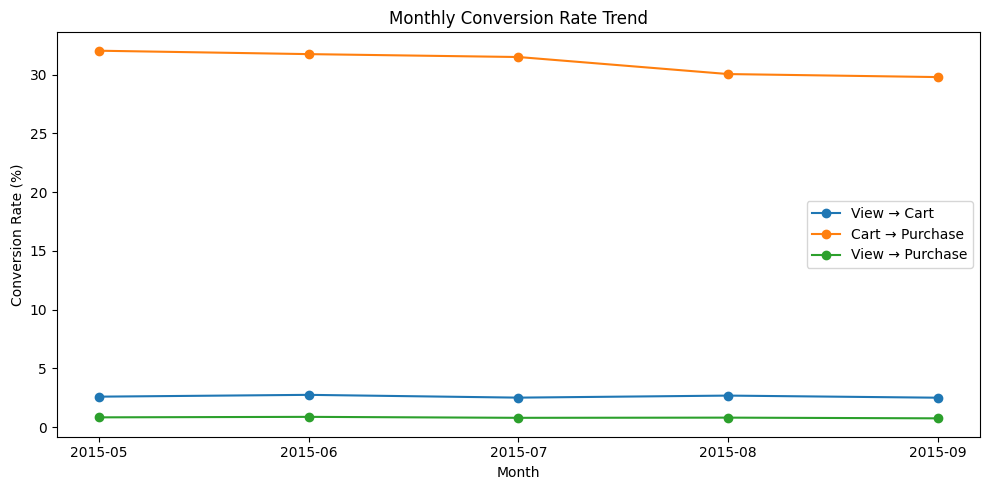

In [19]:
# ============================================================
# 18. Monthly Conversion Trend Chart
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(monthly_funnel["event_month"], monthly_funnel["view_to_cart_rate"] * 100, marker="o", label="View → Cart")
plt.plot(monthly_funnel["event_month"], monthly_funnel["cart_to_purchase_rate"] * 100, marker="o", label="Cart → Purchase")
plt.plot(monthly_funnel["event_month"], monthly_funnel["view_to_purchase_rate"] * 100, marker="o", label="View → Purchase")
plt.title("Monthly Conversion Rate Trend")
plt.xlabel("Month")
plt.ylabel("Conversion Rate (%)")
plt.legend()
plt.tight_layout()
save_chart("02_monthly_conversion_rate_trend.png")
plt.show()

## 6. Baseline Metric Selection for A/B Test

이 프로젝트의 A/B Test Simulation에서는 다음 지표를 baseline으로 사용할 수 있다.

1. `View → Add to Cart`: 상품 상세 페이지, 추천 영역, CTA 버튼 개선 실험에 적합하다.
2. `View → Purchase`: 최종 비즈니스 성과와 직접 연결되지만 baseline이 낮아 더 큰 표본이 필요할 수 있다.
3. `Add to Cart → Purchase`: checkout, 결제, 장바구니 UX 실험에 적합하다.

In [20]:
# ============================================================
# 19. Baseline Metric Table for A/B Test
# ============================================================

baseline_metric_table = pd.DataFrame([
    {
        "metric": "View → Add to Cart",
        "baseline_rate": view_to_cart,
        "baseline_rate_pct": view_to_cart * 100,
        "recommended_use": "Product detail page, recommendation area, CTA experiment",
        "priority": "High",
        "reason": "Largest user-level bottleneck occurs before cart entry.",
    },
    {
        "metric": "View → Purchase",
        "baseline_rate": view_to_purchase,
        "baseline_rate_pct": view_to_purchase * 100,
        "recommended_use": "End-to-end conversion optimization",
        "priority": "Medium",
        "reason": "Directly tied to business outcome but requires larger sample size.",
    },
    {
        "metric": "Add to Cart → Purchase",
        "baseline_rate": cart_to_purchase,
        "baseline_rate_pct": cart_to_purchase * 100,
        "recommended_use": "Cart and checkout UX experiment",
        "priority": "Medium",
        "reason": "Important but not the largest drop-off stage in this dataset.",
    },
])

display(baseline_metric_table)
save_table(baseline_metric_table, "02_ab_test_baseline_metric_table.csv")

,metric,baseline_rate,baseline_rate_pct,recommended_use,priority,reason
0,View → Add to Cart,0.0269,2.6864,"Product detail page, recommendation area, CTA ...",High,Largest user-level bottleneck occurs before ca...
1,View → Purchase,0.0083,0.8346,End-to-end conversion optimization,Medium,Directly tied to business outcome but requires...
2,Add to Cart → Purchase,0.3107,31.0668,Cart and checkout UX experiment,Medium,Important but not the largest drop-off stage i...


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\02_ab_test_baseline_metric_table.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/02_ab_test_baseline_metric_table.csv')

In [21]:
# ============================================================
# 20. Final Funnel Insight Summary
# ============================================================

funnel_insight_summary = pd.DataFrame([
    {
        "insight": "Primary bottleneck",
        "description": "The largest user-level drop-off occurs before users add products to cart.",
    },
    {
        "insight": "Recommended primary metric",
        "description": "View → Add to Cart conversion rate is recommended as the primary A/B Test metric.",
    },
    {
        "insight": "Recommended experiment target",
        "description": "Product detail page, recommendation module, CTA copy, or cart-entry incentive.",
    },
    {
        "insight": "Secondary business metric",
        "description": "View → Purchase conversion rate should be monitored as a downstream business outcome.",
    },
])

display(funnel_insight_summary)
save_table(funnel_insight_summary, "02_funnel_insight_summary.csv")

print("02_event_funnel_analysis completed.")
print("Next notebook: 03_item_category_analysis.ipynb")

,insight,description
0,Primary bottleneck,The largest user-level drop-off occurs before ...
1,Recommended primary metric,View → Add to Cart conversion rate is recommen...
2,Recommended experiment target,"Product detail page, recommendation module, CT..."
3,Secondary business metric,View → Purchase conversion rate should be moni...


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\02_funnel_insight_summary.csv
02_event_funnel_analysis completed.
Next notebook: 03_item_category_analysis.ipynb
